# Task 5: Sales Prediction Using Python
Predict product sales from advertising spend (TV, Radio, Newspaper).

**Dataset:** `Advertising.csv` from Kaggle (place it in the same folder as this notebook).

In [27]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_style('whitegrid')

## 1. Load data and EDA

In [28]:
df = pd.read_csv('Advertising.csv')
# Some versions have an unnamed index column; drop it if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# Make column names consistent regardless of dataset version (tv/TV, radio/Radio ...)
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={'tv': 'TV', 'radio': 'Radio', 'newspaper': 'Newspaper', 'sales': 'Sales'})
print(df.shape)
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [29]:
print('Null values:\n', df.isnull().sum())
df.describe()

Null values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


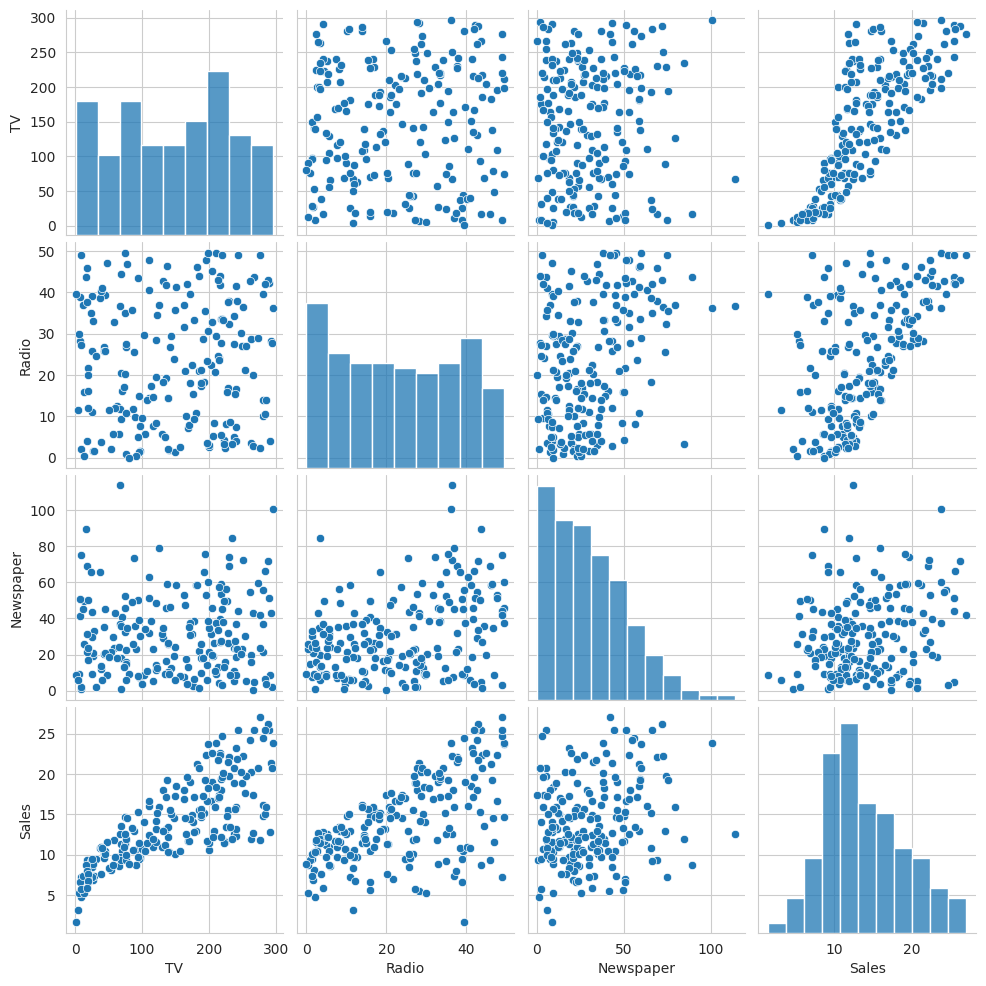

In [30]:
sns.pairplot(df)
plt.show()

## 2. Sales vs each advertising channel

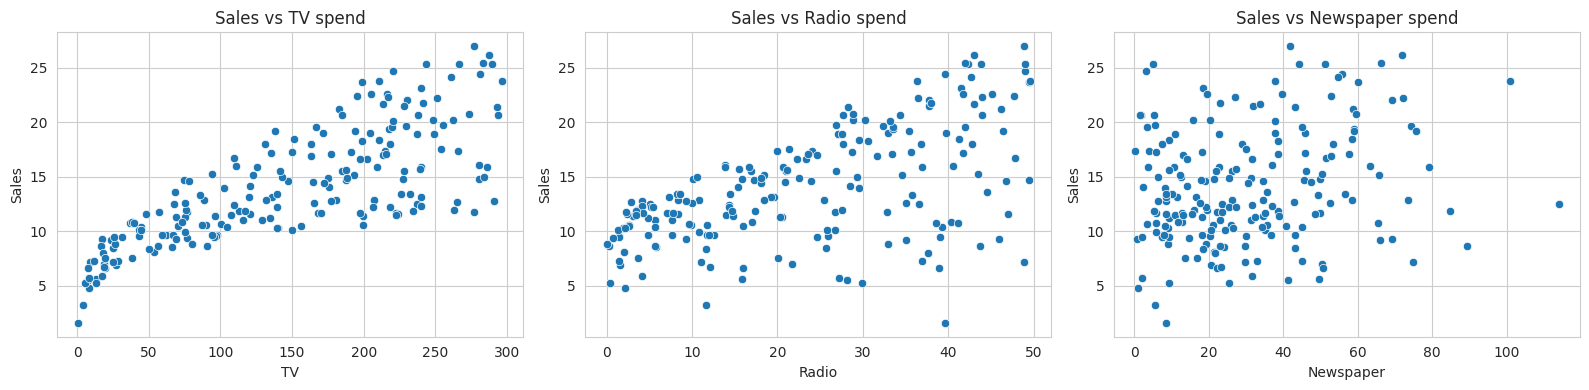

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.scatterplot(x=df[col], y=df['Sales'], ax=ax)
    ax.set_title(f'Sales vs {col} spend')
plt.tight_layout(); plt.show()

## 3. Correlation heatmap

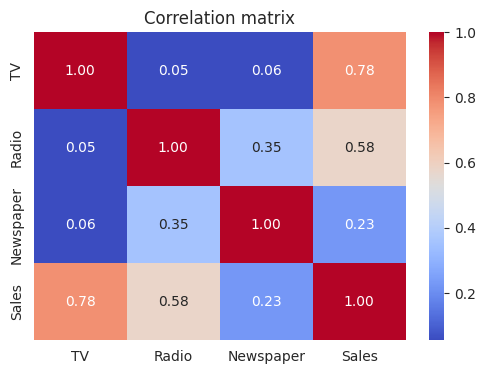

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix'); plt.show()

## 4. Train/test split

In [33]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(160, 3) (40, 3)


## 5. Models: Linear Regression (baseline) and Random Forest

In [34]:
lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
models = {'Linear Regression': lr, 'Random Forest': rf}

## 6. Evaluation (MAE, RMSE, R²)

In [35]:
rows = []
for name, m in models.items():
    p = m.predict(X_test)
    rows.append({'Model': name,
                 'MAE': mean_absolute_error(y_test, p),
                 'RMSE': np.sqrt(mean_squared_error(y_test, p)),
                 'R2': r2_score(y_test, p)})
results = pd.DataFrame(rows).set_index('Model')
results

,MAE,RMSE,R2
Model,,,
Linear Regression,1.460757,1.781600,0.899438
Random Forest,0.628713,0.757235,0.981833


## 7. Residual plot for the best model

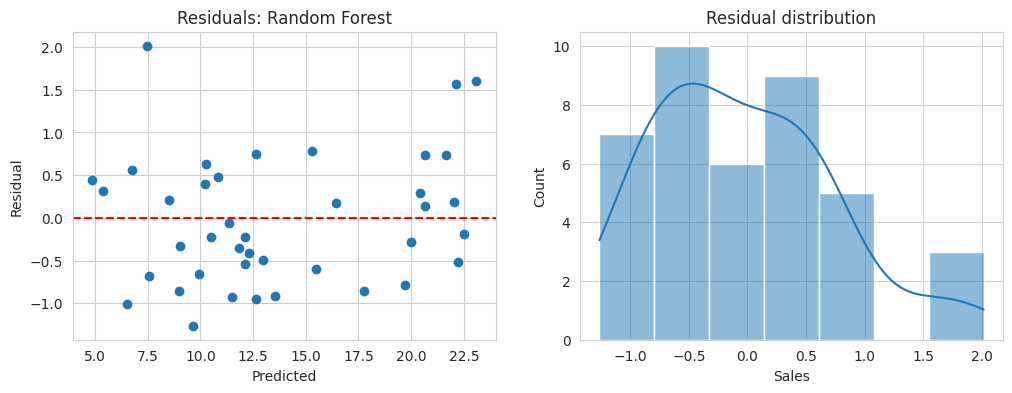

Best model: Random Forest


In [36]:
best_name = results['R2'].idxmax()
best = models[best_name]
pred = best.predict(X_test)
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(pred, resid); ax[0].axhline(0, color='red', ls='--')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Residual'); ax[0].set_title(f'Residuals: {best_name}')
sns.histplot(resid, kde=True, ax=ax[1]); ax[1].set_title('Residual distribution')
plt.show()
print('Best model:', best_name)

**Observation:** The residuals of the Random Forest model are scattered around zero (mostly between -1 and +1) with no clear curve or funnel shape, so the errors are mostly random and the model fits well. The residual distribution is roughly centred at zero. One small pattern: for the highest predicted sales (above about 20), a few residuals are positive, meaning the model slightly under-predicts very high sales. This could be improved with more data or hyperparameter tuning.

## 8. Interpretation: which channel matters most?

           Linear coefficient  RF importance
TV                   0.044730       0.624727
Radio                0.189195       0.362119
Newspaper            0.002761       0.013153


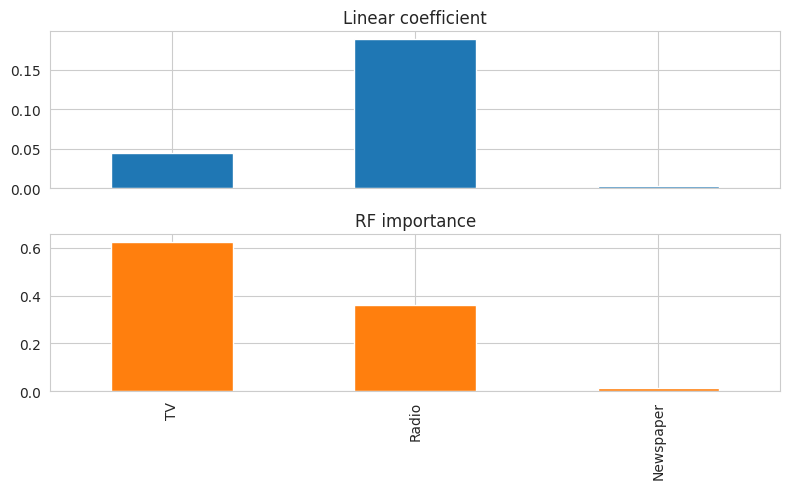

In [37]:
coef = pd.Series(lr.coef_, index=X.columns, name='Linear coefficient')
imp = pd.Series(rf.feature_importances_, index=X.columns, name='RF importance')
print(pd.concat([coef, imp], axis=1))
pd.concat([coef, imp], axis=1).plot(kind='bar', subplots=True, figsize=(8, 5), legend=False)
plt.tight_layout(); plt.show()

**Conclusion:**
- Linear Regression coefficients show Radio has the highest effect per unit of spend (about 0.19), followed by TV (about 0.045). Newspaper is near zero (about 0.003).
- Random Forest feature importance shows TV contributes most to predictions (about 62%), then Radio (about 36%), and Newspaper is negligible (about 1%).
- Overall, TV and Radio drive sales, while Newspaper advertising has almost no impact. The company should focus its budget on TV and Radio.
- Random Forest performed better than Linear Regression (R² about 0.98 vs about 0.90).

